# Credit Card Fraud Detection

## Project Overview

Credit card fraud is a major problem in modern financial systems. 
Banks and payment providers process millions of transactions every day, and detecting fraudulent activity quickly is critical to prevent financial losses.

In this project, we analyze a dataset of credit card transactions in order to identify patterns associated with fraudulent activity.

The dataset contains anonymized transaction information and includes both legitimate and fraudulent transactions. 
Each transaction is described by multiple numerical features representing characteristics of the operation.

The main goal of this project is to explore the dataset, understand the structure and patterns in the data, and build a machine learning model capable of detecting fraudulent transactions.

The analysis includes:
- data exploration
- visualization of transaction patterns
- identification of differences between normal and fraudulent transactions
- building and evaluating classification models

## Problem Understanding

The objective of this project is to detect fraudulent credit card transactions based on transaction data.

Each observation in the dataset represents a single transaction. 
The dataset includes several numerical features describing characteristics of the transaction, as well as a target variable indicating whether the transaction is fraudulent.

The target variable is:

Class:

0 — normal transaction  
1 — fraudulent transaction

This makes the task a **binary classification problem**.

One of the key challenges of this dataset is the strong **class imbalance**. 
Fraudulent transactions represent only a very small percentage of the total transactions, which makes detecting them more difficult.

Therefore, special attention must be given to appropriate evaluation metrics and modeling techniques when building predictive models.

The goal of the analysis is to determine whether transaction features can be used to successfully identify fraudulent activity.

## Data Loading

In this step we load the dataset and inspect the structure of the data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


credit_card_information = pd.read_csv("../src/Data/creditcard.csv")
credit_card_information.head()
 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2.Data Understanding

In [3]:
credit_card_information.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [4]:
credit_card_information.shape

(284807, 31)

In [5]:
credit_card_information.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
credit_card_information.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#### Result Data Understanding

The dataset contains 284,807 transactions and 31 columns.

Each row represents a single credit card transaction, and each column represents a feature describing the transaction.

Most features are numerical variables. The dataset includes:

• Time – the time elapsed between this transaction and the first transaction in the dataset.

• Amount – the transaction amount.

• V1–V28 – anonymized numerical features obtained using PCA to protect sensitive financial information.

• Class – the target variable indicating whether the transaction is fraudulent.

Class values:
0 – normal transaction  
1 – fraudulent transaction

Initial inspection of the dataset shows that all columns contain numerical data types and there are no missing values in the dataset.

## 3.Data Cleaning 
In this step we are cleaning data.

In [7]:
credit_card_information.duplicated().sum()
# before cleaning

np.int64(1081)

In [8]:
credit_card_information = credit_card_information.drop_duplicates()

In [9]:
credit_card_information.duplicated().sum()
# after cleaning

np.int64(0)

In [10]:
# i get this information in step 2, but duplicate it, to make sure.
credit_card_information.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
# Check how much fraud and not fraud i have.
credit_card_information["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

Text(0.5, 1.0, 'Fraud vs Normal Transactions')

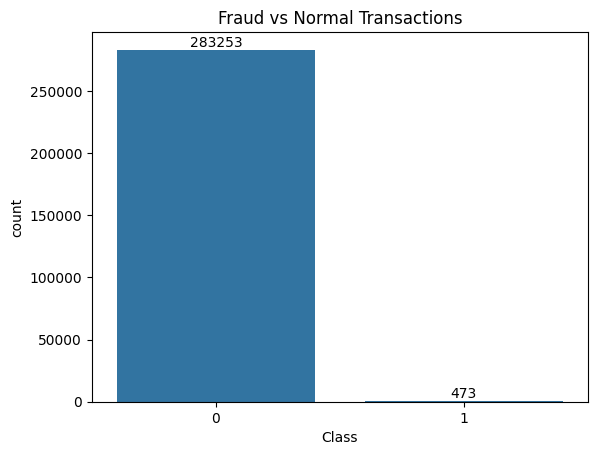

In [12]:
ax = sns.countplot(x = "Class", data=credit_card_information)
ax.bar_label(ax.containers[0])
plt.title("Fraud vs Normal Transactions")


####  Data Cleaning Summary

During the data cleaning step, the dataset was checked for duplicates and missing values.

A total of 1081 duplicate rows were detected in the dataset and removed to avoid redundant information that could bias the analysis and machine learning models.

After removing duplicates, the dataset contains only unique transactions.

Additionally, the dataset was checked for missing values. The inspection confirmed that there are no missing values in any of the columns.

Therefore, the dataset is clean and ready for further exploratory data analysis.

## 4. Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand patterns and relationships within the data.

The goal of EDA is to identify characteristics of fraudulent transactions and compare them with normal transactions using statistical analysis and visualizations.

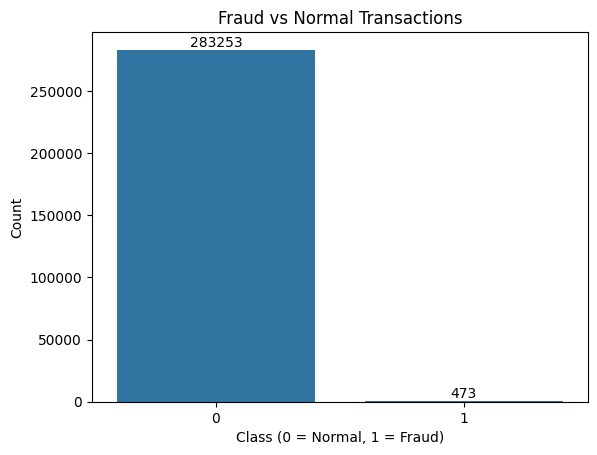

In [13]:
# class distribution
ax = sns.countplot(x="Class", data=credit_card_information)

ax.bar_label(ax.containers[0])

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

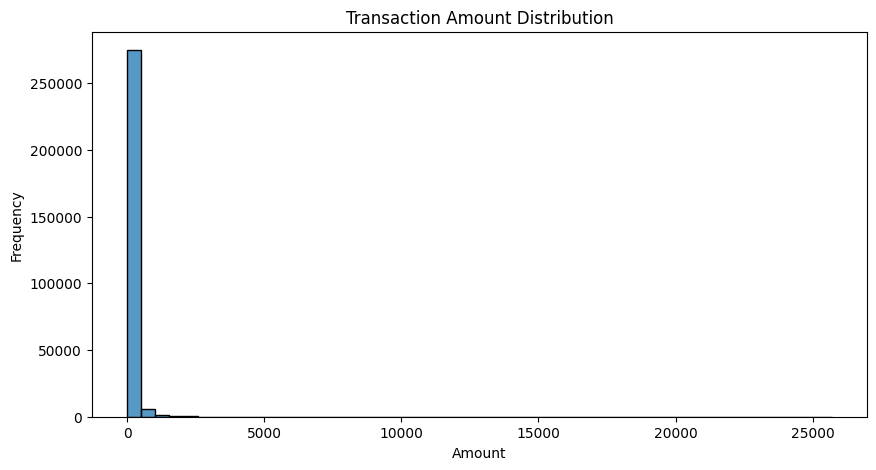

In [14]:
# Amount distribution
plt.figure(figsize=(10,5))

sns.histplot(credit_card_information["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

Text(0, 0.5, 'Count')

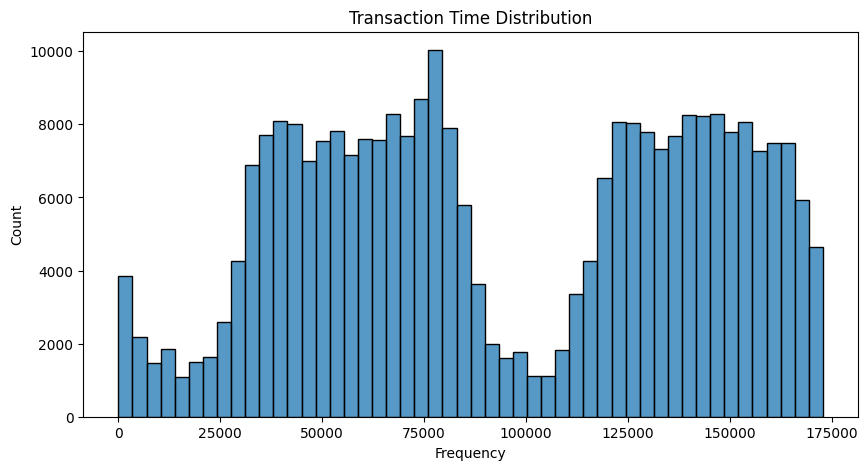

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(credit_card_information["Time"], bins=50)

plt.title("Transaction Time Distribution")

plt.xlabel("Frequency")
plt.ylabel("Count")


Text(0.5, 1.0, 'Transaction Amount by Class')

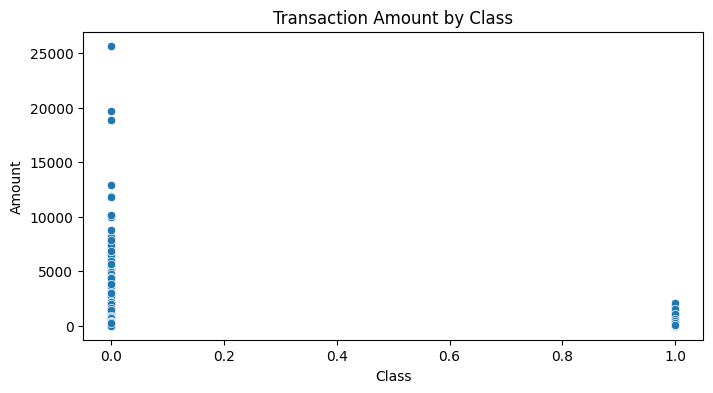

In [16]:
plt.figure(figsize=(8,4))

sns.scatterplot(x="Class", y="Amount", data=credit_card_information)

plt.title("Transaction Amount by Class")





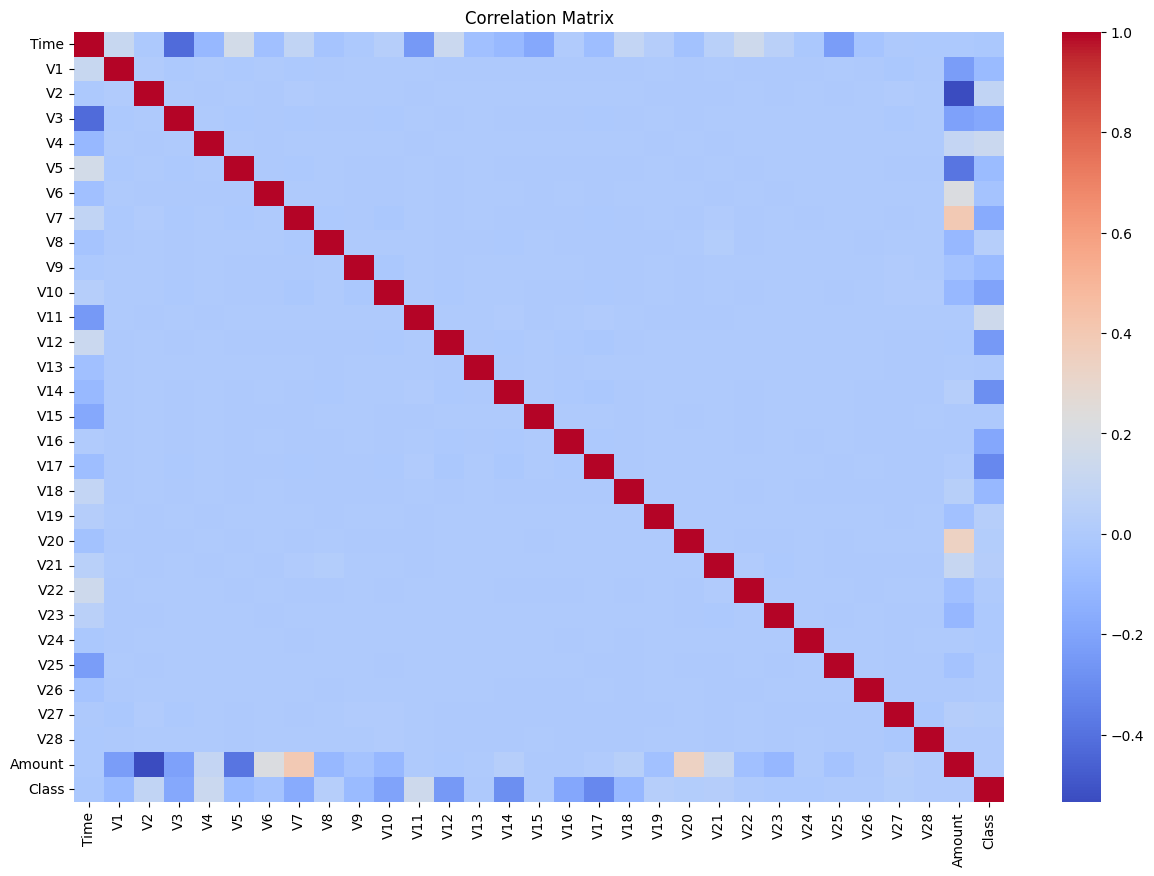

In [17]:
plt.figure(figsize=(15,10))

sns.heatmap(credit_card_information.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [18]:
corr = credit_card_information.corr()["Class"].sort_values()
print(corr)

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V6       -0.043915
Time     -0.012359
V24      -0.007210
V23      -0.006333
V13      -0.003897
V15      -0.003300
V25       0.003202
V26       0.004265
V22       0.004887
Amount    0.005777
V28       0.009682
V20       0.021486
V27       0.021892
V21       0.026357
V8        0.033068
V19       0.033631
V2        0.084624
V4        0.129326
V11       0.149067
Class     1.000000
Name: Class, dtype: float64


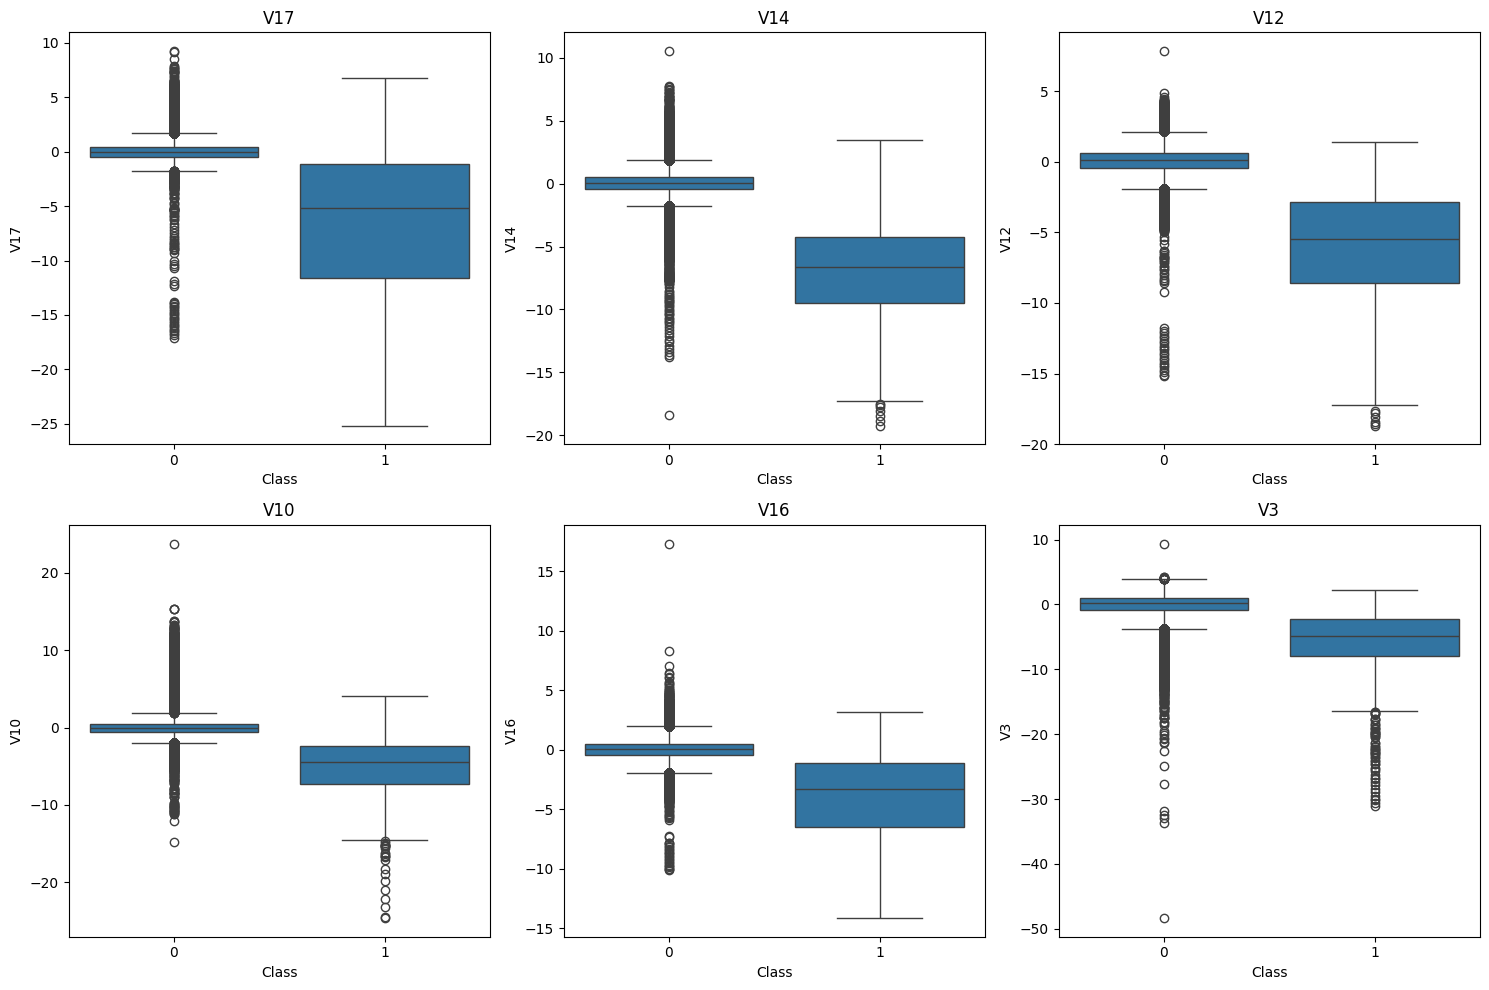

In [22]:
features = ["V17", "V14", "V12","V10","V16","V3"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x="Class", y=col, data=credit_card_information)
    plt.title(col)

plt.tight_layout()

#### The exploratory data analysis revealed several important insights about the dataset and the nature of fraudulent transactions.

1. The dataset is highly imbalanced:
   The vast majority of transactions are normal (~99.83%), while fraudulent transactions represent only a small fraction (~0.17%). 
   This makes fraud detection a challenging classification problem and requires special handling during modeling.

2. No missing values and minimal data issues:
   The dataset is clean, with no missing values and duplicates removed, ensuring reliable analysis and modeling.

3. Transaction amount distribution:
   The 'Amount' feature is highly skewed, with most transactions being small and a few extreme outliers representing large transactions.

4. Time distribution:
   The 'Time' feature shows periodic patterns, suggesting that transactions occur in cycles rather than uniformly over time.

5. Strong correlation with specific features:
   Several features (V17, V14, V12, V10, V16, V3) show the strongest correlation with the target variable (Class).

6. Clear separation between classes:
   Boxplot analysis of the most important features shows that fraudulent transactions have significantly different distributions 
   compared to normal transactions, often shifted toward lower (negative) values.

7. Feature usefulness:
   The strong separation and correlation indicate that these features carry high predictive power for detecting fraud.

Overall, the dataset contains meaningful patterns that can be leveraged by machine learning models to distinguish between 
fraudulent and normal transactions.